# Praca dyplomowa
## Odporność modeli NLP na ataki zwodnicze przy różnych rodzajach osadzeń (nie jestem pewna jak nazwać prace)

### Wstępne pytania badawcze:
* Czy rodzaj osadzeń wpływa na podatność modeli na ataki zwodnicze?
* Czy poziom preprocessingu wpływa na odporność modelu?
* Które typy ataków są najskuteczniejsze dla danego modelu?

## Eksploracyjna analiza danych (EDA)
### IMDB Dataset of 50K Movie Reviews
Zbiór danych wykorzystywany w niniejszej pracy pochodzi z platformy Kaggle i zawiera 50 tysięcy recenzji filmowych wraz z przypisanym do nich sentymentem. Każda obserwacja składa się z treści recenzji oraz etykiety określającej jej wydźwięk jako pozytywny lub negatywny.

Dane mają charakter tekstowy i nieustrukturyzowany, co jest charakterystyczne dla zadań z zakresu przetwarzania języka naturalnego (Natural Language Preprocessing). Recenzje różnią się długością, stylem oraz poziomem formalności języka. Występują w nich elementy takie jak znaczniki HTML, znaki specjalne oraz język potoczny, co odzwierciedla rzeczywiste dane pochodzące od użytkowników.

Celem eksploracyjnej analizy danych jest szczegółowe poznanie stróktury zbioru, wskazanie jego najważniejszych cech oraz rozpoznanie potencjalnych trudności związanych z dalszym przetwarzaniem i budową modeli. Analiza ta stanowi podstawę do podejmowania decyzji dotyczących przygotowania danych, wyboru sposobu reprezentacji tekstu oraz oceny odporności modeli na ataki zwodnicze.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
url = "https://raw.githubusercontent.com/gajafi/nlp-adversarial-attacks/main/data/raw/IMDB%20Dataset.csv"
df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 1. Struktura danych

Na wstępnym etapie przeanalizowano strukturę zbioru danych, w tym liczbę obserwacji, typy zmiennych oraz obecność brakujących wartości. Zbiór składa się z dwóch kolumn: tekstowej („review”) oraz kategorycznej („sentiment”). Nie zaobserwowano brakujących danych, co upraszcza dalszy proces analizy i modelowania.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


Analiza podstawowych statystyk wykazała, że w zbiorze danych występują powtarzające się recenzje, jednak ich liczba jest niewielka w stosunku do całkowitej liczby obserwacji.

Najczęściej występująca recenzja pojawia się pięciokrotnie.

In [4]:
df.duplicated(subset='review').sum()

np.int64(418)

Znaczna większość recenzji jest unikalna. 418 recenzji pojawia się więcej niż raz.

In [5]:
df.isna().sum()

,0
review,0
sentiment,0


### 2. Rozkład klas

Następnie przeprowadzono analizę rozkładu klas sentymentu. Zbiór danych zawiera równą liczbę recenzji pozytywnych i negatywnych, co oznacza że jest zbalansowany. Dzięki temu nie ma potrzeby stosowania dodatkowych metod równoważenia klas, a uzyskane wyniki modeli klasyfikacyjnych można uznać za bardziej miarodajne.

In [6]:
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


### 3. Długość tekstów

Przeprowadzono analizę długości recenzji wyrażonej liczbą słów. Średnia długość tekstu wynosi około 231 słów, przy czym mediana jest niższa i wynosi 173 słowa, co wskazuje na asymetrię rozkładu. Odchylenie standardowe na poziomie 171 świadczy o dużej zmienności długości recenzji.

In [7]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['word_count'].describe()

,word_count
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


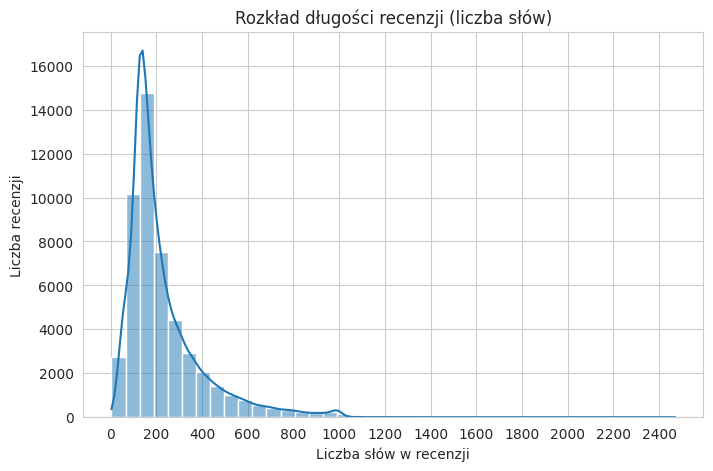

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.xticks(np.arange(0, df['word_count'].max(), 200))
plt.ylabel("Liczba recenzji")
plt.xlabel("Liczba słów w recenzji")
plt.title("Rozkład długości recenzji (liczba słów)")
plt.show()

Na wykresie można zaobserwować, że rozkład ma charakter wyraźnie prawoskośny, co oznacza, że większość recenzji jest stosunkowo krótka, natomiast występuje niewielka liczba bardzo długich tekstów. Największe zagęszczenie obserwacji przypada na zakres około 100-300 słów.

Wraz ze wzrostem liczby słów liczba obserwacji systematycznie maleje, co potwierdza obecność długiego „ogona” rozkładu. Oznacza to, że choć bardzo długie recenzje występują rzadko, mogą znacząco wpływać na statystyki opisowe, takie jak średnia. Wykres potwierdza również występowanie wartości odstających, sięgających nawet powyżej 2000 słów.

In [9]:
df['word_count'].quantile([0.5, 0.9, 0.95, 0.99])

,word_count
0.50,173.0
0.90,451.0
0.95,590.0
0.99,908.0


Analiza kwartylowa pokazuje, że 50% recenzji zawiera od 126 do 280 słów, natomiast 90% obserwacji nie przekracza 451 słów. Jednocześnie występują bardzo długie recenzje, sięgające nawet 2470 słów, co potwierdza obecność wartości odstających.

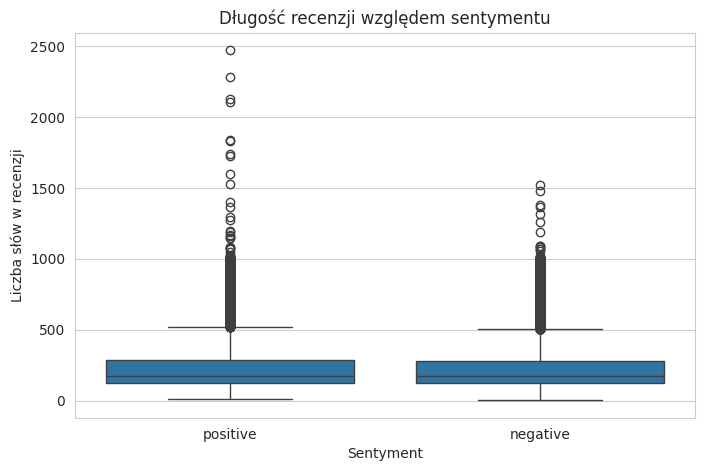

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment', y='word_count')
plt.ylabel("Liczba słów w recenzji")
plt.xlabel("Sentyment")
plt.title("Długość recenzji względem sentymentu")
plt.show()

Wykres pudełkowy przedstawia długość recenzji w zależności od sentymentu. Rozkłady dla recenzji pozytywnych i negatywnych są bardzo zbliżone — zarówno mediany, jak i zakresy międzykwartylowe mają podobne wartości. W obu grupach widoczny jest długi ogon w prawo. W przypadku recenzji pozytywnych występują pojedyncze, wyjątkowo długie teksty (sięgające ok. 2500 słów). W grupie recenzji negatywnych wartości odstające również są obecne, jednak nie osiągają tak dużych wartości. Oznacza to, że użytkownicy sporadycznie piszą bardzo rozbudowane pozytywne recenzje, podczas gdy ekstremalnie długie negatywne recenzje pojawiają się rzadziej.

In [11]:
df['char_count'] = df['review'].apply(len)
df['char_count'].describe()

,char_count
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


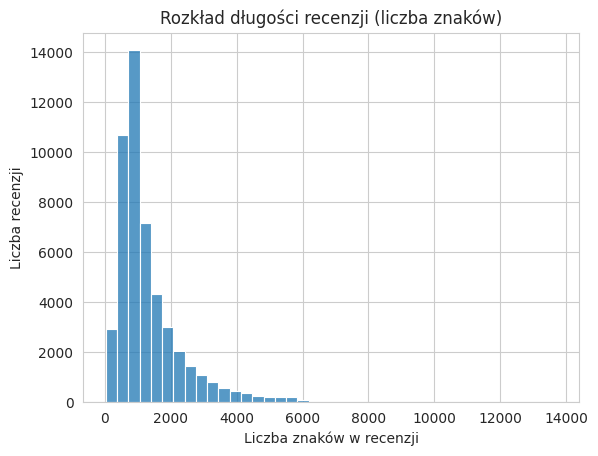

In [12]:
sns.histplot(df['char_count'], bins=40)
plt.ylabel("Liczba recenzji")
plt.xlabel("Liczba znaków w recenzji")
plt.title("Rozkład długości recenzji (liczba znaków)")
plt.show()

Przykładowe recenzje

In [13]:
df['review'].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [14]:
df['review'].iloc[1234]

'The 20th animated Disney classic is often criticized by many people as "mediocre" or poor in quality, but it is a great movie.<br /><br />Too bad that "The Aristocats" doesn\'t get the deserved credit. I personally see it as one of my favorite Disney classics.<br /><br />Despite being extremely underrated, it is one of the funniest Disney classics. It is full of hilarious (some of them, hysterical) moments.<br /><br />Edgar, the greedy butler, is the villain of the movie but he is a perfect comic relief. He\'s one of my favorite Disney villains because he is so funny.<br /><br />Every scene with Edgar and the hound dogs Napoleon and Lafayette chasing him are among the most hilarious you\'ll ever see, especially the one when Edgar drives his motorcycle into the river and around the bridge, with the dogs chasing him. That is hysterical!<br /><br />But the classic humor doesn\'t just come from Edgar or the hound dogs. Other characters have their moments as well.<br /><br />About the qual

In [15]:
df['review'].iloc[36]

"The plot is about the death of little children. Hopper is the one who has to investigate the killings. During the movie it appears that he has some troubles with his daughter. In the end the serial killer get caught. That's it. But before you find out who dunnit, you have to see some terrible acting by all of the actors. It is unbelievable how bad these actors are, including Hopper. I could go on like this but that to much of a waste of my time. Just don't watch the movie. I've warned you."

### 4. Analiza surowego tekstu

Przeprowadzona analiza wykazała, że znaczniki HTML występują w znacznej części zbioru danych. Oznacza to, że 29 200 (~58%) recenzji zawiera elementy formatowania, które nie niosą bezpośredniej wartości semantycznej.


In [16]:
df['contains_html'] = df['review'].str.contains('<br />')
df['contains_html'].value_counts()

,count
contains_html,
True,29200
False,20800


Obecność znaczników HTML wskazuje na konieczność uwzględnienia odpowiedniego preprocessingu danych. Elementy te mogą wprowadzać szum oraz wpływać na działanie modeli przetwarzania języka naturalnego, dlatego ich usunięcie zostanie rozważone w dalszych etapach analizy.

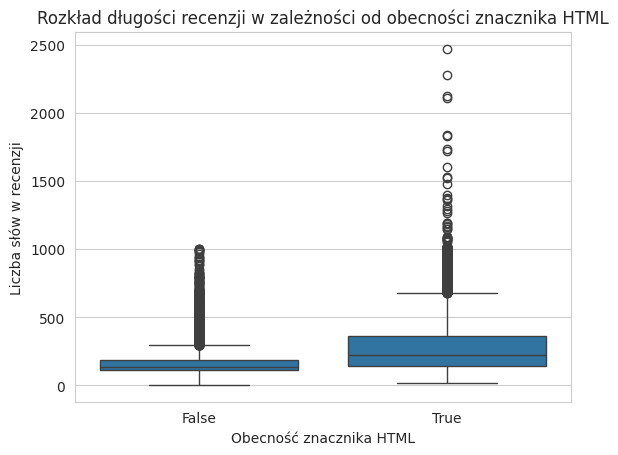

In [17]:
sns.boxplot(data=df, x='contains_html', y='word_count')
plt.title("Rozkład długości recenzji w zależności od obecności znacznika HTML")
plt.xlabel("Obecność znacznika HTML")
plt.ylabel("Liczba słów w recenzji")
plt.show()

Analiza długości recenzji w zależności od obecności znaczników HTML wykazała, że recenzje zawierające HTML są przeciętnie dłuższe oraz charakteryzują się większą zmiennością. Mediana liczby słów dla tej grupy jest wyższa, a rozkład obejmuje większą liczbę wartości odstających, co wskazuje na obecność bardzo rozbudowanych wypowiedzi.

### 5. Najczęściej występujace słowa

In [18]:
from collections import Counter

all_words = " ".join(df['review']).lower().split()
common_words = Counter(all_words).most_common(20)
common_words

[('the', 638861),
 ('a', 316615),
 ('and', 313637),
 ('of', 286661),
 ('to', 264573),
 ('is', 204876),
 ('in', 179807),
 ('i', 141587),
 ('this', 138483),
 ('that', 130140),
 ('it', 129614),
 ('/><br', 100974),
 ('was', 93258),
 ('as', 88242),
 ('with', 84590),
 ('for', 84510),
 ('but', 77864),
 ('on', 62890),
 ('movie', 61492),
 ('are', 57009)]

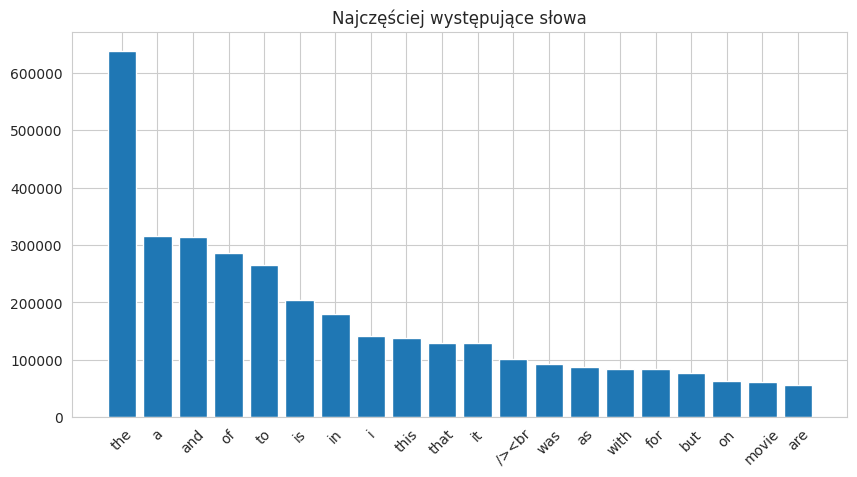

In [19]:
words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Najczęściej występujące słowa")
plt.show()

Analiza najczęściej występujących słów w zbiorze IMDB pokazuje, że dominują w nim typowe angielskie stopwords, takie jak „the”, „a”, „and”, „of” czy „to”. Jest to zgodne z charakterystyką naturalnego języka, w którym stopwords stanowią znaczną część tekstu. Wśród najczęstszych tokenów pojawia się również artefakt HTML („/><br”), co potwierdza konieczność oczyszczenia danych na etapie preprocessingu. Jedynym słowem niosącym treść w pierwszej dwudziestce jest „movie”, co odzwierciedla tematykę recenzji. Wyniki te wskazują, że surowe dane wymagają wstępnego przetwarzania, a obecność dużej liczby stopwords może wpływać na działanie klasycznych modeli NLP oraz na podatność modeli na ataki zwodnicze.

In [20]:
pos_words = " ".join(pos['review']).lower().split()
neg_words = " ".join(neg['review']).lower().split()

Counter(pos_words).most_common(10)

[('the', 326268),
 ('and', 171379),
 ('a', 160990),
 ('of', 150754),
 ('to', 129608),
 ('is', 108994),
 ('in', 95642),
 ('i', 66833),
 ('it', 64793),
 ('this', 64167)]

In [21]:
Counter(neg_words).most_common(10)

[('the', 312593),
 ('a', 155625),
 ('and', 142258),
 ('of', 135907),
 ('to', 134965),
 ('is', 95882),
 ('in', 84165),
 ('i', 74754),
 ('this', 74316),
 ('that', 66232)]

nie ma to sensu na razie bo stopwords w obu klasach

In [22]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

stopword_ratio = df['review'].apply(
    lambda x: sum(1 for w in x.lower().split() if w in stop_words) / len(x.split())
)

stopword_ratio.describe()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review
count,50000.000000
mean,0.453379
std,0.048744
min,0.000000
25%,0.423611
50%,0.455056
75%,0.485294
max,0.666667


Przeanalizowano udział stopwords w recenzjach, obliczając stosunek liczby słów uznawanych za stopwords do całkowitej liczby słów w tekście. Średni udział stopwords wyniósł 45%, co jest typowe dla języka angielskiego i wskazuje na naturalny, użytkowy charakter recenzji. Niewielkie odchylenie standardowe (0.048) sugeruje, że styl pisania użytkowników jest stosunkowo jednorodny. Wartości skrajne (0-0.66) pokazują, że w zbiorze występują zarówno bardzo zwięzłe recenzje, jak i długie, narracyjne opisy. Analiza ta jest istotna w kontekście preprocessingu, ponieważ usunięcie stopwords może znacząco zmienić strukturę tekstu i wpłynąć na odporność modeli na ataki zwodnicze.

In [23]:
import re

def special_char_ratio(text):
    return len(re.findall(r"[^a-zA-Z0-9\s]", text)) / len(text)

df['special_char_ratio'] = df['review'].apply(special_char_ratio)
df['special_char_ratio'].describe()

,special_char_ratio
count,50000.000000
mean,0.040340
std,0.015892
min,0.000000
25%,0.029798
50%,0.038251
75%,0.048186
max,0.427492


In [24]:
df[['word_count', 'char_count', 'special_char_ratio']].corr()

,word_count,char_count,special_char_ratio
word_count,1.000000,0.99683,-0.013983
char_count,0.996830,1.00000,-0.002980
special_char_ratio,-0.013983,-0.00298,1.000000


## Preprocessing

In [25]:
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### Poziom 0 - minimalne przetworzenie

In [26]:
def preprocess_level_0(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)  # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    return text.strip()

### Poziom 1 -średnie przetworzenie

In [27]:
def preprocess_level_1(text):
    text = preprocess_level_0(text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

### Poziom 2 - mocniejsze przetworzenie

In [28]:
def preprocess_level_2(text):
    text = preprocess_level_1(text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 2]  # remove short words
    return " ".join(tokens)